# Wind Speed Prediction using CNN-LSTM model

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import csv
import os

# Data Preprocessing and Analysis

In [3]:
import math
import seaborn as sns
import datetime as dt
from datetime import datetime    
sns.set_style("whitegrid")
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("ggplot")

In [4]:
# For data preprocessing and analysis part
# data = pd.read_csv('data/imputation_data/0.1missing_rate/gain.csv', header=None)
# data = pd.read_csv('data/imputation_data/0.2missing_rate/gain.csv')
# data = pd.read_csv('data/imputation_data/0.3missing_rate/gain.csv')
# data = pd.read_csv('data/imputation_data/0.4missing_rate/gain.csv')
# data = pd.read_csv('mean.csv')
# data = pd.read_csv('data/wind_speed.csv')
data.columns = ['WTG3', 'WTG4', 'WTG5', 'WTG6', 'WTG7', 'WTG8', 'WTG9', 'WTG10']
data.head(10)

,WTG3,WTG4,WTG5,WTG6,WTG7,WTG8,WTG9,WTG10
0,14.6,17.0,18.1,16.5,16.5,16.7,15.7,16.0
1,16.1,17.5,17.5,17.8,16.9,17.8,15.3,15.9
2,13.9,17.8,17.1,16.6,15.5,17.5,17.5,16.0
3,12.9,17.1,16.7,16.4,16.0,17.6,16.2,15.0
4,14.5,16.2,16.6,16.0,15.7,16.8,15.4,14.8
5,13.6,16.5,16.3,14.6,13.9,15.6,14.8,16.5
6,14.0,16.7,17.7,15.3,13.1,15.7,18.4,15.6
7,11.6,17.2,16.2,15.3,13.4,15.9,17.0,15.4
8,13.0,16.9,16.6,16.0,14.5,16.7,16.6,14.9
9,12.4,16.9,16.3,14.4,13.0,15.4,17.5,15.8


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   WTG3    4463 non-null   float64
 1   WTG4    4463 non-null   float64
 2   WTG5    4463 non-null   float64
 3   WTG6    4463 non-null   float64
 4   WTG7    4463 non-null   float64
 5   WTG8    4463 non-null   float64
 6   WTG9    4463 non-null   float64
 7   WTG10   4463 non-null   float64
dtypes: float64(8)
memory usage: 279.1 KB


In [6]:
data.describe()

,WTG3,WTG4,WTG5,WTG6,WTG7,WTG8,WTG9,WTG10
count,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000
mean,7.554112,7.842908,8.661170,7.494959,7.706879,8.661685,7.913242,7.129128
std,2.746175,2.926902,2.889993,2.776144,2.633928,2.931992,3.040624,2.888559
min,1.400000,1.100000,1.000000,0.900000,1.000000,0.900000,0.700000,1.100000
25%,5.400000,5.500000,6.400000,5.400000,5.700000,6.400000,5.400000,4.700000
50%,7.200000,7.300000,8.400000,7.000000,7.400000,8.400000,7.700000,6.700000
75%,9.600000,9.900000,10.700000,9.300000,9.200000,10.900000,10.000000,9.200000
max,17.200000,17.800000,18.100000,17.800000,17.600000,17.800000,18.400000,17.700000


Then the datasets are loaded

In [75]:
data.isnull().sum()

WTG3     0
WTG4     0
WTG5     0
WTG6     0
WTG7     0
WTG8     0
WTG9     0
WTG10    0
dtype: int64

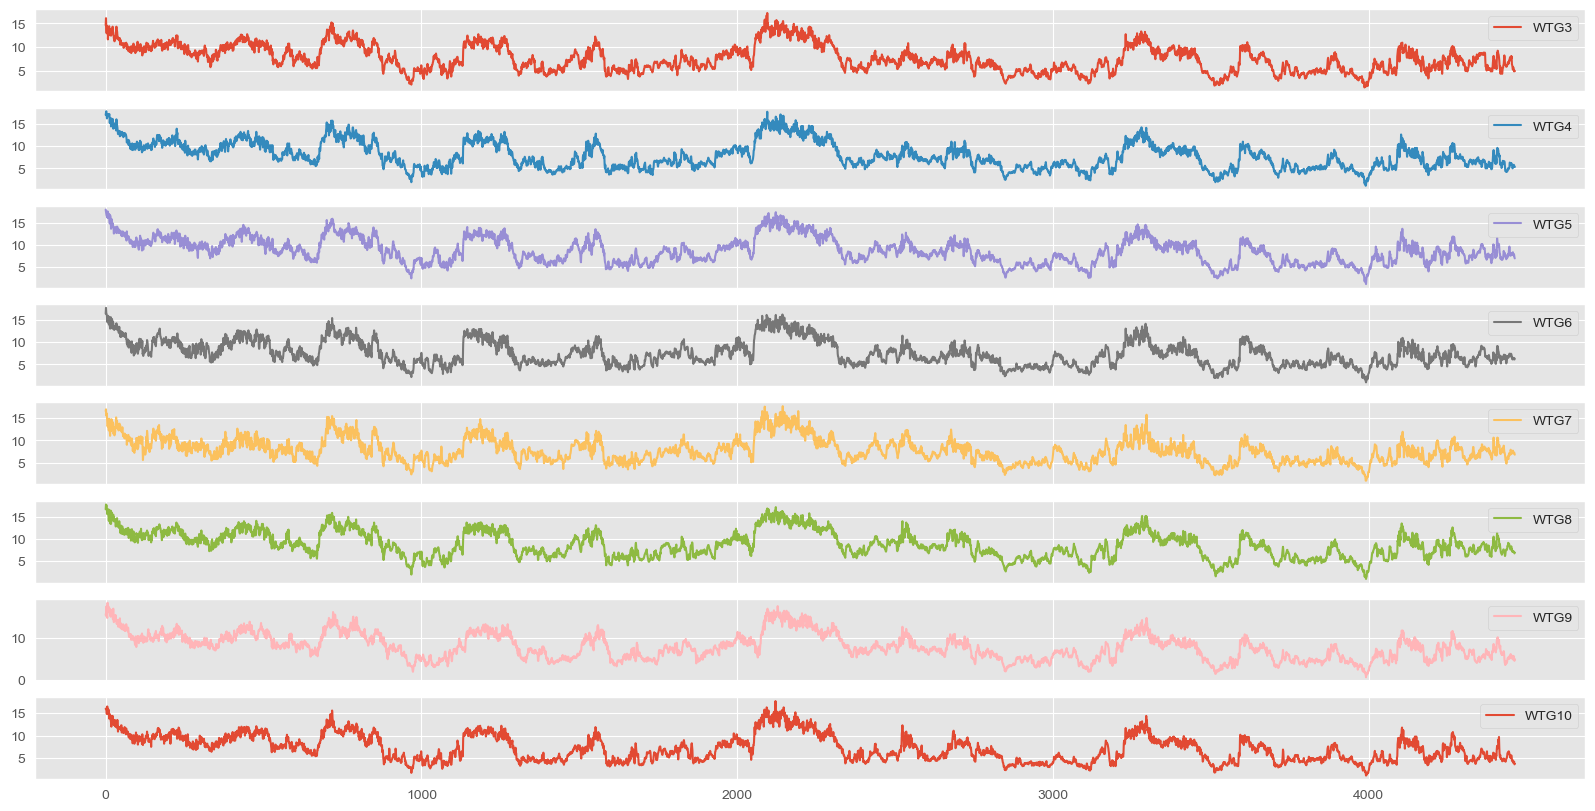

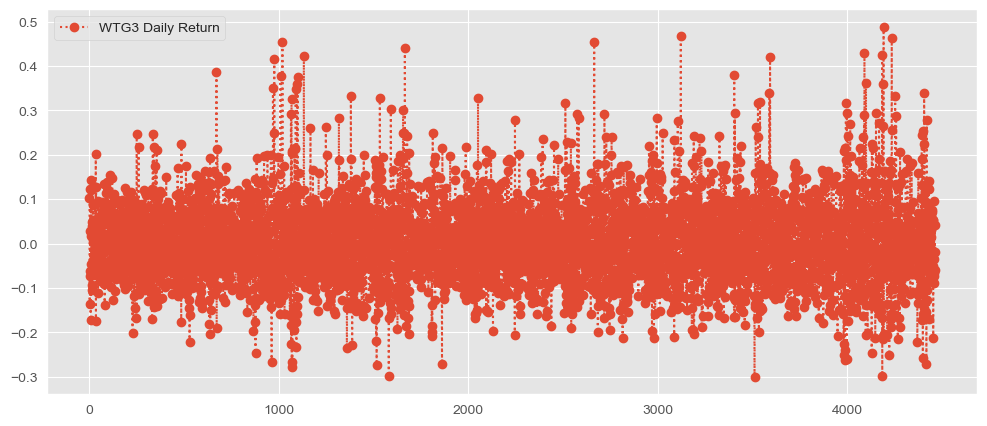

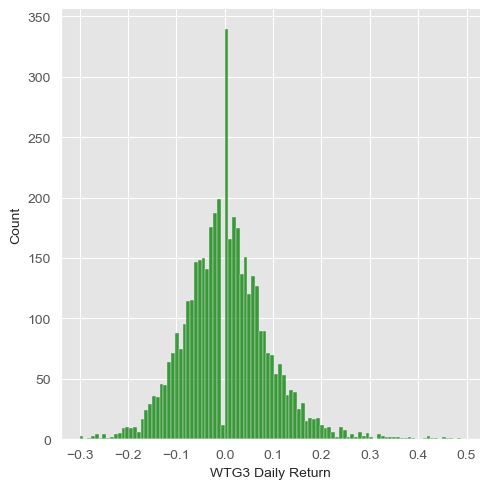

      WTG3  WTG4  WTG5  WTG6  WTG7  WTG8  WTG9  WTG10  WTG3 MA for 0.5 hours  \
0     14.6  17.0  18.1  16.5  16.5  16.7  15.7   16.0                    NaN   
1     16.1  17.5  17.5  17.8  16.9  17.8  15.3   15.9                    NaN   
2     13.9  17.8  17.1  16.6  15.5  17.5  17.5   16.0              14.866667   
3     12.9  17.1  16.7  16.4  16.0  17.6  16.2   15.0              14.300000   
4     14.5  16.2  16.6  16.0  15.7  16.8  15.4   14.8              13.766667   
...    ...   ...   ...   ...   ...   ...   ...    ...                    ...   
4458   5.5   5.3   7.6   6.2   7.1   7.1   5.6    3.9               5.466667   
4459   5.1   5.8   7.9   6.4   7.1   7.1   5.7    4.2               5.433333   
4460   4.8   5.4   7.7   6.1   7.3   6.9   5.0    4.2               5.133333   
4461   5.0   5.5   7.1   6.1   7.0   6.7   4.6    3.6               4.966667   
4462   4.9   5.3   6.9   6.3   6.8   6.9   5.0    3.7               4.900000   

      WTG3 MA for 1.0 hours  ...  WTG10

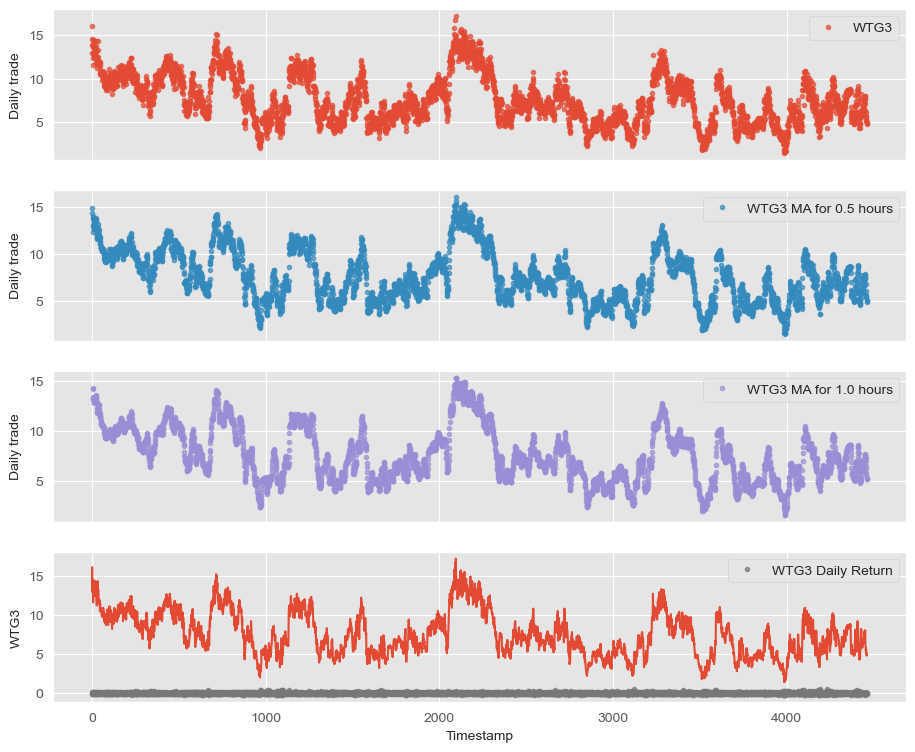

In [76]:
data.plot(legend=True,subplots=True, figsize = (20, 10))
plt.show()
# data['WTG03'].plot(legend=True, figsize = (10, 2))
# plt.show()


data.shape
data.size
data.describe(include='all').T
data.dtypes
data.nunique()
step_size = [3, 6]
for j in range(3, 11):
    for i in step_size:
        column_name = 'WTG%s' % j + ' MA for %s hours' %(str(i/6))
        data[column_name]=pd.DataFrame.rolling(data['WTG%s' % j ],i).mean()
        
for n in range(3, 11):
    Daily_Return = data['WTG%s' % n].pct_change()
    data['WTG%s' % n + ' Daily Return'] = Daily_Return

# plot the daily return percentage
data['WTG3 Daily Return'].plot(figsize=(12,5),legend=True,linestyle=':',marker='o')
plt.show()
sns.displot(data['WTG3 Daily Return'].dropna(),bins=100,color='green')
plt.show()

# date = pd.DataFrame(data['date'])
# wind_speed = pd.DataFrame(data['WTG3'])
# speed1 = wind_speed.rename(columns={"WTG3": "wind_speed"})
# speed2 = pd.concat([date,speed1],axis=1)
# speed2.head(10)

data.sort_index(axis=1,ascending=True)
cols_plot = ['WTG3', 'WTG3 MA for 0.5 hours', 'WTG3 MA for 1.0 hours', 'WTG3 Daily Return']
axes = data[cols_plot].plot(marker='.', alpha=0.7, linestyle='None', figsize=(11, 9), subplots=True)
for ax in axes:
    ax.set_ylabel('Daily trade')

plt.plot(data['WTG3'], label="WTG3")
plt.xlabel("Timestamp")
plt.ylabel("WTG3")
df = data
print(df)
plt.show()

After that, we'll visualize the data for understanding, this is shown below...

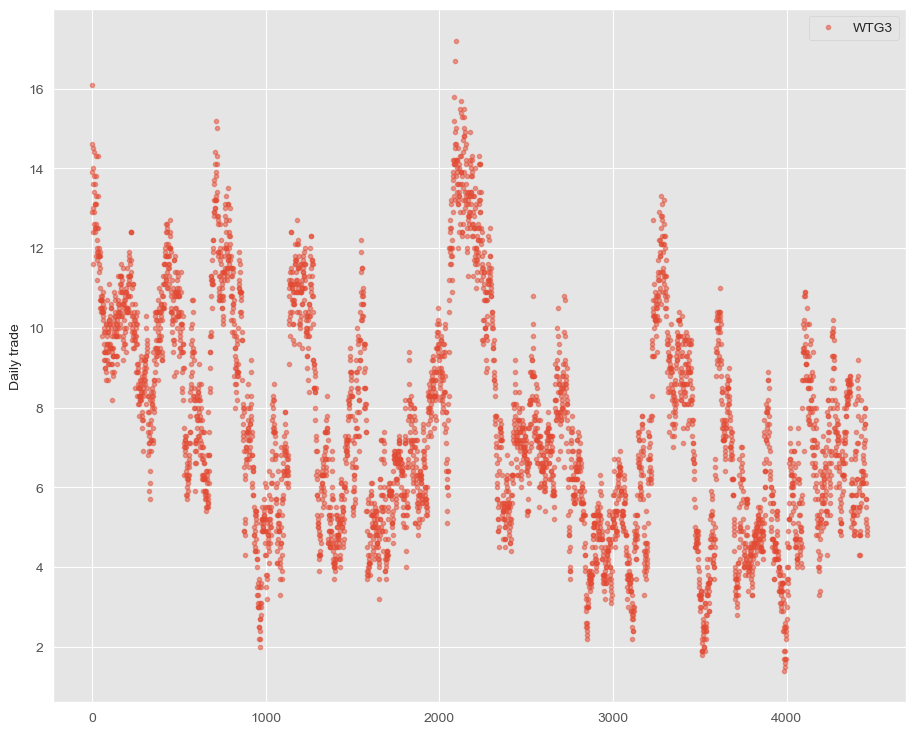

In [77]:
cols_plot = ['WTG3']
axes = data[cols_plot].plot(marker='.', alpha=0.5, linestyle='None', figsize=(11, 9), subplots=True)
for ax in axes:
    ax.set_ylabel('Daily trade')

Then we'd print the data after making changes 

      WTG3  WTG4  WTG5  WTG6  WTG7  WTG8  WTG9  WTG10  WTG3 MA for 0.5 hours  \
0     14.6  17.0  18.1  16.5  16.5  16.7  15.7   16.0                    NaN   
1     16.1  17.5  17.5  17.8  16.9  17.8  15.3   15.9                    NaN   
2     13.9  17.8  17.1  16.6  15.5  17.5  17.5   16.0              14.866667   
3     12.9  17.1  16.7  16.4  16.0  17.6  16.2   15.0              14.300000   
4     14.5  16.2  16.6  16.0  15.7  16.8  15.4   14.8              13.766667   
...    ...   ...   ...   ...   ...   ...   ...    ...                    ...   
4458   5.5   5.3   7.6   6.2   7.1   7.1   5.6    3.9               5.466667   
4459   5.1   5.8   7.9   6.4   7.1   7.1   5.7    4.2               5.433333   
4460   4.8   5.4   7.7   6.1   7.3   6.9   5.0    4.2               5.133333   
4461   5.0   5.5   7.1   6.1   7.0   6.7   4.6    3.6               4.966667   
4462   4.9   5.3   6.9   6.3   6.8   6.9   5.0    3.7               4.900000   

      WTG3 MA for 1.0 hours  ...  WTG10

,WTG3,WTG4,WTG5,WTG6,WTG7,WTG8,WTG9,WTG10,WTG3 MA for 0.5 hours,WTG3 MA for 1.0 hours,...,WTG10 MA for 0.5 hours,WTG10 MA for 1.0 hours,WTG3 Daily Return,WTG4 Daily Return,WTG5 Daily Return,WTG6 Daily Return,WTG7 Daily Return,WTG8 Daily Return,WTG9 Daily Return,WTG10 Daily Return
count,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000,4463.000000,4461.000000,4458.000000,...,4461.000000,4458.000000,4462.000000,4462.000000,4462.000000,4462.000000,4462.000000,4462.000000,4462.000000,4462.000000
mean,7.554112,7.842908,8.661170,7.494959,7.706879,8.661685,7.913242,7.129128,7.553008,7.551593,...,7.127923,7.126125,0.003722,0.003548,0.003085,0.005087,0.005320,0.003416,0.003853,0.004173
std,2.746175,2.926902,2.889993,2.776144,2.633928,2.931992,3.040624,2.888559,2.714292,2.690512,...,2.854655,2.829945,0.090199,0.088659,0.082530,0.104479,0.106366,0.086615,0.092184,0.096462
min,1.400000,1.100000,1.000000,0.900000,1.000000,0.900000,0.700000,1.100000,1.533333,1.633333,...,1.200000,1.416667,-0.300000,-0.360000,-0.370370,-0.368421,-0.444444,-0.464286,-0.461538,-0.396825
25%,5.400000,5.500000,6.400000,5.400000,5.700000,6.400000,5.400000,4.700000,5.366667,5.383333,...,4.700000,4.716667,-0.054211,-0.052632,-0.047619,-0.059701,-0.061224,-0.048544,-0.053333,-0.052632
50%,7.200000,7.300000,8.400000,7.000000,7.400000,8.400000,7.700000,6.700000,7.133333,7.116667,...,6.666667,6.675000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.600000,9.900000,10.700000,9.300000,9.200000,10.900000,10.000000,9.200000,9.566667,9.566667,...,9.200000,9.150000,0.053715,0.050000,0.047619,0.060606,0.061224,0.047619,0.052275,0.056604
max,17.200000,17.800000,18.100000,17.800000,17.600000,17.800000,18.400000,17.700000,16.033333,15.300000,...,15.966667,15.700000,0.488372,0.642857,0.900000,0.666667,0.651163,0.928571,1.142857,0.739130


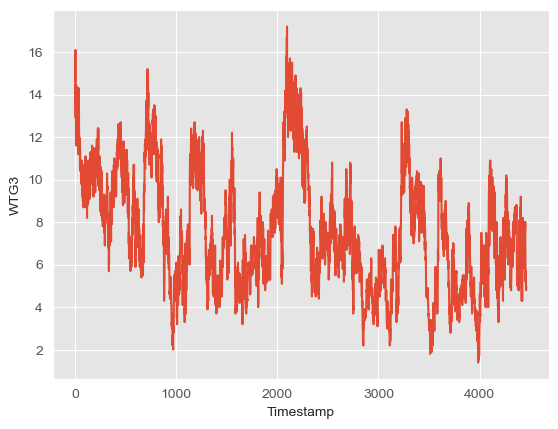

In [78]:
plt.plot(data['WTG3'], label="WTG03")
plt.xlabel("Timestamp")
plt.ylabel("WTG3")
df = data
print(df)
df.to_csv('df.csv')
df.describe()

date data splitting

In [79]:
import pandas as pd
df1 = df.copy()
# for i in ['minute', 'hour', 'day', 'month', 'year']:
#     date_splitting = pd.read_csv('date_data/date_splitting.csv', usecols=[i])
#     df1.insert(0, i, date_splitting)
# df1 = df1.drop(['date'], axis=1)
# print(df1)
# df1.to_csv('df1.csv')

特征选择

In [80]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_regression
df1 = df1.dropna()
df1 = df1.reset_index(drop=True)
Feature_X = df1.drop(columns=['WTG3'])
Feature_Y = df1.loc[:, 'WTG3']

K = 5
k_best_features = SelectKBest(score_func=mutual_info_regression, k=K)
X_new = k_best_features.fit_transform(Feature_X, Feature_Y)
X_new = pd.DataFrame(X_new)
df2 = pd.concat([X_new, Feature_Y], axis=1, ignore_index=True)
print(df2)

         0          1          2          3         4     5
0     16.5  13.666667  14.266667  16.600000 -0.062069  13.6
1     16.7  14.033333  14.166667  16.466667  0.029412  14.0
2     17.2  13.066667  13.416667  16.800000 -0.171429  11.6
3     16.9  12.866667  13.266667  16.933333  0.120690  13.0
4     16.9  12.333333  13.183333  17.000000 -0.046154  12.4
...    ...        ...        ...        ...       ...   ...
4453   5.3   5.466667   5.750000   5.333333 -0.035088   5.5
4454   5.8   5.433333   5.550000   5.500000 -0.072727   5.1
4455   5.4   5.133333   5.333333   5.500000 -0.058824   4.8
4456   5.5   4.966667   5.216667   5.566667  0.041667   5.0
4457   5.3   4.900000   5.166667   5.400000 -0.020000   4.9

[4458 rows x 6 columns]


In [81]:
# from sklearn.preprocessing import MinMaxScaler
# df2 = df1.copy()
# col_index = df1.columns
# df2 = df2.dropna()
# df2 = df2.reset_index(drop=True)
# scaler = MinMaxScaler()
# scaler.fit(df2)
# norm_df2 = scaler.transform(df2)
# df2 = pd.DataFrame(df_array, columns=col_index)
# print(df2)

adf检验确认时间步长

In [82]:
from statsmodels.tsa.stattools import adfuller
time_series = df2.iloc[:, K]
adf_result = adfuller(time_series, autolag='AIC')
time_step = adf_result[2]
print(time_step)

3


相空间重构

In [83]:
from utils import series_to_supervised
df3 = series_to_supervised(df2, time_step, 1)
df3 = df3.reset_index(drop=True)
print(df3)
df3.to_csv('df3.csv', index=False)

      var1(t-3)  var2(t-3)  var3(t-3)  var4(t-3)  var5(t-3)  var6(t-3)  \
0          16.5  13.666667  14.266667  16.600000  -0.062069       13.6   
1          16.7  14.033333  14.166667  16.466667   0.029412       14.0   
2          17.2  13.066667  13.416667  16.800000  -0.171429       11.6   
3          16.9  12.866667  13.266667  16.933333   0.120690       13.0   
4          16.9  12.333333  13.183333  17.000000  -0.046154       12.4   
...         ...        ...        ...        ...        ...        ...   
4450        5.0   6.033333   6.950000   5.400000  -0.065574        5.7   
4451        5.3   5.666667   6.483333   5.266667  -0.087719        5.2   
4452        5.4   5.533333   6.166667   5.233333   0.096154        5.7   
4453        5.3   5.466667   5.750000   5.333333  -0.035088        5.5   
4454        5.8   5.433333   5.550000   5.500000  -0.072727        5.1   

      var1(t-2)  var2(t-2)  var3(t-2)  var4(t-2)  ...  var3(t-1)  var4(t-1)  \
0          16.7  14.033333  14.1

划分训练集，测试集和验证集

In [84]:
from sklearn.model_selection import train_test_split

X = df3.iloc[:, :df2.shape[1] * time_step].values.tolist()
Y = df3.loc[:, 'var6(t)'].values.tolist()
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, shuffle=False)
x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.5, shuffle=False)
train_X = np.array(x_train)
test_X = np.array(x_test)
train_Y = np.array(y_train).reshape(-1, 1)
test_Y = np.array(y_test).reshape(-1, 1)
val_X = np.array(x_val)
val_Y = np.array(y_val).reshape(-1, 1)

最大最小归一化

In [85]:
from sklearn.preprocessing import MinMaxScaler
scaler_train_X = MinMaxScaler()
scaler_train_X.fit(train_X)
scaler_train_Y = MinMaxScaler()
scaler_train_Y.fit(train_Y)
scaler_test_X = MinMaxScaler()
scaler_test_X.fit(test_X)
scaler_test_Y = MinMaxScaler()
scaler_test_Y.fit(test_Y)
scaler_val_X = MinMaxScaler()
scaler_val_X.fit(val_X)
scaler_val_Y = MinMaxScaler()
scaler_val_Y.fit(val_Y)
train_X = scaler_train_X.transform(train_X)
test_X = scaler_test_X.transform(test_X)
train_Y = scaler_train_Y.transform(train_Y)
test_Y = scaler_test_Y.transform(test_Y)
val_X = scaler_val_X.transform(val_X)
val_Y = scaler_val_Y.transform(val_Y)

train_X = train_X.reshape(train_X.shape[0], time_step, df2.shape[1])
test_X = test_X.reshape(test_X.shape[0], time_step, df2.shape[1])
val_X = val_X.reshape(val_X.shape[0], time_step, df2.shape[1])
print(len(x_train))
print(len(x_test))
print(len(x_val))

2673
891
891


# Training part

This part has 2 subparts: CNN and LSTM

For CNN, the layers are created with sizes 64,128,64 with kernel size = 3. In every layer, TimeDistributed function is added to track the features for every temporal slice of data with respect to time. In between, MaxPooling layers are added.

After that, it's passed to Bi-LSTM layers

In [86]:
# For creating model and training
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, LSTM, GRU, Dense, Dropout, Bidirectional, TimeDistributed
from tensorflow.keras.layers import MaxPooling1D, Flatten
from tensorflow.keras.regularizers import L1, L2
from tensorflow.keras.metrics import Accuracy
from tensorflow.keras.metrics import RootMeanSquaredError
# tf.config.list_physical_devices('GPU')

model = tf.keras.Sequential()

# Creating the Neural Network model here...
# CNN layers
model.add((Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_step, df2.shape[1]))))
model.add((MaxPooling1D(1)))
# model.add(Conv1D(128, kernel_size=3, activation='relu'))
# model.add(MaxPooling1D(2))
# model.add(Conv1D(64, kernel_size=3, activation='relu'))
# model.add(MaxPooling1D(2))
# model.add((Flatten()))
model.add(Dense(32, kernel_regularizer=L2(0.001)))

# LSTM layers
# model.add(Bidirectional(LSTM(16, return_sequences=True)))
# model.add(Dropout(0.8))
model.add(Bidirectional(LSTM(16, return_sequences=False)))
# model.add(Bidirectional(GRU(8, return_sequences=False)))
# model.add(Bidirectional(GRU(4, return_sequences=False)))
model.add(Dropout(0.05))


#Final layers
model.add(Dense(1))
learning_rate = 0.0001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mse', 'mae'])

history = model.fit(train_X, train_Y, validation_data=(test_X,test_Y), epochs=200, batch_size=64, verbose=1, shuffle=False)

Epoch 1/200
42/42 [==============================] - 4s 27ms/step - loss: 0.2059 - mse: 0.1633 - mae: 0.3676 - val_loss: 0.1676 - val_mse: 0.1256 - val_mae: 0.3013
Epoch 2/200
42/42 [==============================] - 0s 7ms/step - loss: 0.1375 - mse: 0.0960 - mae: 0.2745 - val_loss: 0.1087 - val_mse: 0.0677 - val_mae: 0.2117
Epoch 3/200
42/42 [==============================] - 0s 6ms/step - loss: 0.0834 - mse: 0.0428 - mae: 0.1724 - val_loss: 0.0668 - val_mse: 0.0266 - val_mae: 0.1241
Epoch 4/200
42/42 [==============================] - 0s 6ms/step - loss: 0.0531 - mse: 0.0133 - mae: 0.0904 - val_loss: 0.0492 - val_mse: 0.0099 - val_mae: 0.0766
Epoch 5/200
42/42 [==============================] - 0s 7ms/step - loss: 0.0444 - mse: 0.0055 - mae: 0.0590 - val_loss: 0.0451 - val_mse: 0.0068 - val_mae: 0.0668
Epoch 6/200
42/42 [==============================] - 0s 6ms/step - loss: 0.0422 - mse: 0.0043 - mae: 0.0523 - val_loss: 0.0437 - val_mse: 0.0063 - val_mae: 0.0647
Epoch 7/200
42/42 [==

42/42 [==============================] - 0s 7ms/step - loss: 0.0147 - mse: 0.0028 - mae: 0.0408 - val_loss: 0.0149 - val_mse: 0.0031 - val_mae: 0.0435
Epoch 52/200
42/42 [==============================] - 0s 7ms/step - loss: 0.0143 - mse: 0.0026 - mae: 0.0401 - val_loss: 0.0146 - val_mse: 0.0031 - val_mae: 0.0436
Epoch 53/200
42/42 [==============================] - 0s 7ms/step - loss: 0.0140 - mse: 0.0026 - mae: 0.0405 - val_loss: 0.0142 - val_mse: 0.0030 - val_mae: 0.0431
Epoch 54/200
42/42 [==============================] - 0s 7ms/step - loss: 0.0138 - mse: 0.0027 - mae: 0.0402 - val_loss: 0.0141 - val_mse: 0.0032 - val_mae: 0.0437
Epoch 55/200
42/42 [==============================] - 0s 6ms/step - loss: 0.0135 - mse: 0.0026 - mae: 0.0402 - val_loss: 0.0138 - val_mse: 0.0031 - val_mae: 0.0434
Epoch 56/200
42/42 [==============================] - 0s 6ms/step - loss: 0.0132 - mse: 0.0026 - mae: 0.0401 - val_loss: 0.0136 - val_mse: 0.0031 - val_mae: 0.0435
Epoch 57/200
42/42 [=========

42/42 [==============================] - 0s 8ms/step - loss: 0.0063 - mse: 0.0024 - mae: 0.0382 - val_loss: 0.0067 - val_mse: 0.0029 - val_mae: 0.0411
Epoch 102/200
42/42 [==============================] - 0s 8ms/step - loss: 0.0061 - mse: 0.0023 - mae: 0.0374 - val_loss: 0.0065 - val_mse: 0.0027 - val_mae: 0.0403
Epoch 103/200
42/42 [==============================] - 0s 8ms/step - loss: 0.0061 - mse: 0.0023 - mae: 0.0376 - val_loss: 0.0065 - val_mse: 0.0027 - val_mae: 0.0403
Epoch 104/200
42/42 [==============================] - 0s 8ms/step - loss: 0.0060 - mse: 0.0023 - mae: 0.0373 - val_loss: 0.0064 - val_mse: 0.0028 - val_mae: 0.0407
Epoch 105/200
42/42 [==============================] - 0s 8ms/step - loss: 0.0059 - mse: 0.0023 - mae: 0.0373 - val_loss: 0.0064 - val_mse: 0.0028 - val_mae: 0.0408
Epoch 106/200
42/42 [==============================] - 0s 8ms/step - loss: 0.0058 - mse: 0.0023 - mae: 0.0374 - val_loss: 0.0063 - val_mse: 0.0028 - val_mae: 0.0406
Epoch 107/200
42/42 [===

Epoch 151/200
42/42 [==============================] - 0s 7ms/step - loss: 0.0038 - mse: 0.0021 - mae: 0.0361 - val_loss: 0.0044 - val_mse: 0.0028 - val_mae: 0.0398
Epoch 152/200
42/42 [==============================] - 0s 8ms/step - loss: 0.0038 - mse: 0.0022 - mae: 0.0367 - val_loss: 0.0041 - val_mse: 0.0026 - val_mae: 0.0386
Epoch 153/200
42/42 [==============================] - 0s 8ms/step - loss: 0.0038 - mse: 0.0022 - mae: 0.0364 - val_loss: 0.0044 - val_mse: 0.0028 - val_mae: 0.0401
Epoch 154/200
42/42 [==============================] - 0s 9ms/step - loss: 0.0038 - mse: 0.0022 - mae: 0.0364 - val_loss: 0.0041 - val_mse: 0.0026 - val_mae: 0.0387
Epoch 155/200
42/42 [==============================] - 0s 8ms/step - loss: 0.0037 - mse: 0.0021 - mae: 0.0357 - val_loss: 0.0041 - val_mse: 0.0026 - val_mae: 0.0386
Epoch 156/200
42/42 [==============================] - 0s 10ms/step - loss: 0.0037 - mse: 0.0022 - mae: 0.0361 - val_loss: 0.0044 - val_mse: 0.0029 - val_mae: 0.0404
Epoch 157

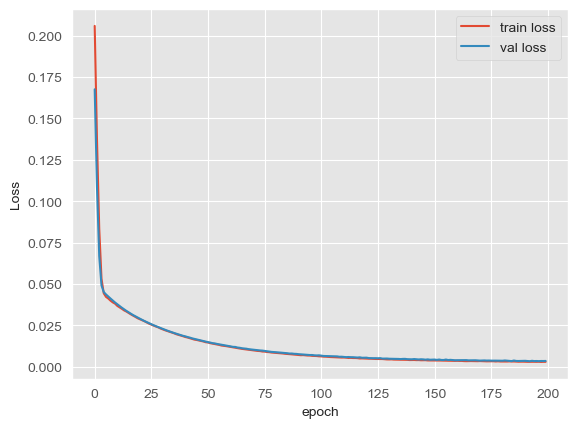

In [87]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.legend()

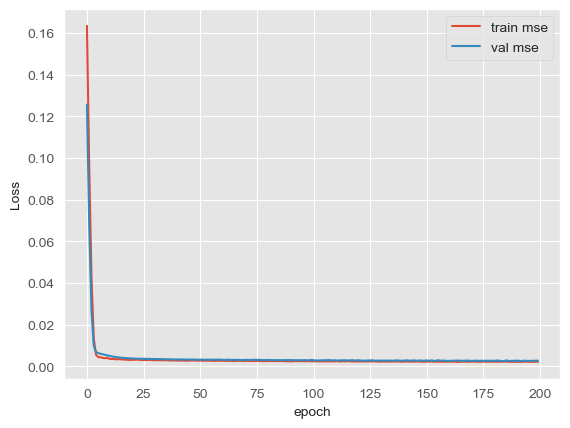

In [88]:
plt.plot(history.history['mse'], label='train mse')
plt.plot(history.history['val_mse'], label='val mse')
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.legend()

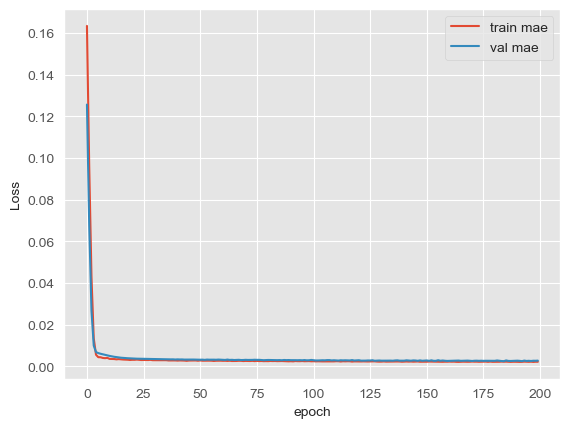

In [89]:
plt.plot(history.history['mse'], label='train mae')
plt.plot(history.history['val_mse'], label='val mae')
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.legend()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 1, 64)             1216      
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 1, 64)            0         
 1D)                                                             
                                                                 
 dense_4 (Dense)             (None, 1, 32)             2080      
                                                                 
 bidirectional_2 (Bidirectio  (None, 32)               6272      
 nal)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                

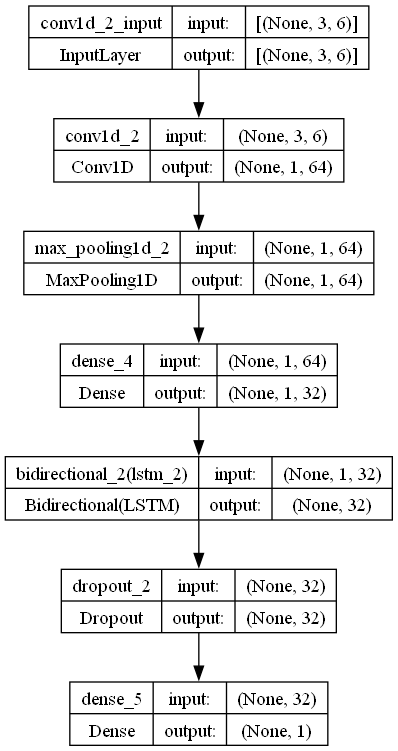

In [90]:
# After the model has been constructed, we'll summarise it
from tensorflow.keras.utils import plot_model
print(model.summary())
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [91]:
model.evaluate(test_X, test_Y)

28/28 [==============================] - 0s 2ms/step - loss: 0.0035 - mse: 0.0027 - mae: 0.0390


[0.003534614806994796, 0.002665855223312974, 0.039004646241664886]

In [92]:
from sklearn.metrics import explained_variance_score, mean_poisson_deviance, mean_gamma_deviance
from sklearn.metrics import r2_score
from sklearn.metrics import max_error, mean_squared_error

# predict probabilities for test set
y_probs = model.predict(test_X, verbose=0)
y_probs = y_probs.reshape(-1, 1)
y_probs = scaler_test_Y.inverse_transform(y_probs)
y_probs = y_probs.reshape(-1, 1)
re_test_Y = scaler_test_Y.inverse_transform(test_Y)
re_test_Y = re_test_Y.reshape(-1, 1)

mse = mean_squared_error(re_test_Y, y_probs)
print('rmse: %f' % mse)

var = explained_variance_score(re_test_Y, y_probs)
print('Variance: %f' % var)

r2 = r2_score(re_test_Y, y_probs)
print('R2 Score: %f' % r2)

var2 = max_error(re_test_Y, y_probs)
print('Max Error: %f' % var2)

rmse: 0.352559
Variance: 0.949335
R2 Score: 0.945666
Max Error: 3.117345


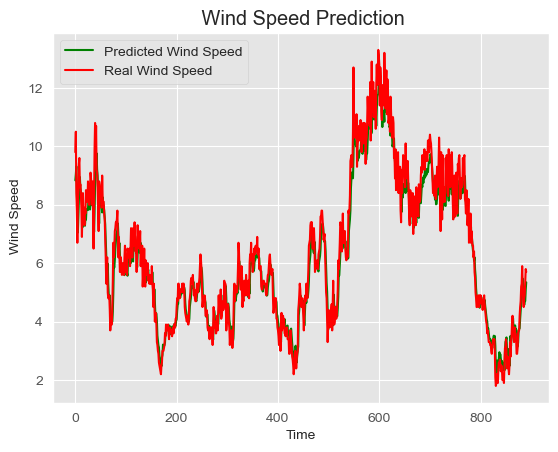

In [93]:
predicted  = y_probs
test_label = re_test_Y
plt.plot(predicted, color = 'green', label = 'Predicted Wind Speed')
plt.plot(test_label, color = 'red', label = 'Real Wind Speed ')
plt.title(' Wind Speed Prediction')
plt.xlabel('Time')
plt.ylabel(' Wind Speed')
plt.legend()
plt.show()

# Testing part

In this part, the model is saved and loaded back again. Then, it's made to train again but with different data to check it's loss and prediction

In [94]:
# First we need to save a model
model.save("model.h5")

In [95]:
# Load model
new_model = tf.keras.models.load_model("./model.h5")

In [96]:
new_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 1, 64)             1216      
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 1, 64)            0         
 1D)                                                             
                                                                 
 dense_4 (Dense)             (None, 1, 32)             2080      
                                                                 
 bidirectional_2 (Bidirectio  (None, 32)               6272      
 nal)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                

In [97]:
model.evaluate(val_X, val_Y)

28/28 [==============================] - 0s 2ms/step - loss: 0.0062 - mse: 0.0053 - mae: 0.0547


[0.006206002086400986, 0.005337242037057877, 0.054711610078811646]

In [98]:
# predict probabilities for test set
y_probs_val = model.predict(val_X, verbose=0)
y_probs_val = y_probs_val.reshape(-1, 1)
y_probs_val = scaler_val_Y.inverse_transform(y_probs_val)
y_probs_val = y_probs_val.reshape(-1, 1)
re_val_Y = scaler_val_Y.inverse_transform(val_Y)
re_val_Y = re_val_Y.reshape(-1, 1)

val_mse = mean_squared_error(re_val_Y, y_probs_val)
print('rmse: %f' % val_mse)

val_var = explained_variance_score(re_val_Y, y_probs_val)
print('Variance: %f' % val_var)

val_r2 = r2_score(re_val_Y, y_probs_val)
print('R2 Score: %f' % val_r2)

val_var2 = max_error(re_val_Y, y_probs_val)
print('Max Error: %f' % val_var2)


rmse: 0.491880
Variance: 0.882207
R2 Score: 0.861596
Max Error: 2.866305


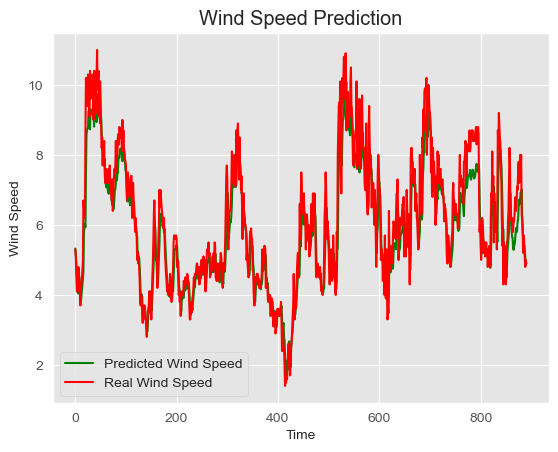

In [99]:
predicted_val  = y_probs_val
val_label = re_val_Y
plt.plot(predicted_val, color = 'green', label = 'Predicted Wind Speed')
plt.plot(val_label, color = 'red', label = 'Real Wind Speed')
plt.title('Wind Speed Prediction')
plt.xlabel('Time')
plt.ylabel('Wind Speed')
plt.legend()
plt.show()